Question 1: The Two-State Weather ModelIn a fictional town, the weather each day can only be either Sunny ($S$) or Rainy ($R$).
The weather tomorrow depends only on the weather today according to these rules:
If today is Sunny, there is an 80% chance tomorrow will be Sunny, and a 20% chance it will be Rainy.If today is Rainy, there is a 40% chance tomorrow will be Sunny, and a 60% chance it will be Rainy.

Write a simple Python script to simulate this weather track for 10 days, starting from a Rainy day.

In [24]:
import random

# Define states: 0 for Sunny, 1 for Rainy
SUNNY = 0
RAINY = 1
"""
State transition rules
P[current_state][next_state]
Nested lookup dictionary: P[current_state] finds today's
row, and [next_state] gets the probability for tomorrow.
"""
P = {
    SUNNY: {SUNNY: 0.8, RAINY: 0.2},
    RAINY: {SUNNY: 0.4, RAINY: 0.6}
}

current_state = RAINY # Initial state for Day 0
weather_history = ['Rainy'] # Record for Day 0

random.seed(42)
for day_num in range(1, 11): # Simulate Day 1 through Day 10 (10 iterations)
  probs = P[current_state]
  roll = random.random()

  # Determine the next state
  if current_state == SUNNY:
    if roll < probs[SUNNY]:
      current_state = SUNNY
    else:
      current_state = RAINY
  else: # current_state == RAINY
    if roll < probs[SUNNY]: # This is P[RAINY][SUNNY]
      current_state = SUNNY
    else: # This is P[RAINY][RAINY]
      current_state = RAINY

  # Append the new current_state (which represents the weather for day_num)
  weather_history.append("Sunny" if current_state == SUNNY else "Rainy")

# Print the history for Day 0 to Day 10
for i, weather in enumerate(weather_history):
  print(f"Day {i}: {weather}")

Day 0: Rainy
Day 1: Sunny
Day 2: Rainy
Day 3: Rainy
Day 4: Sunny
Day 5: Sunny
Day 6: Sunny
Day 7: Rainy
Day 8: Rainy
Day 9: Sunny
Day 10: Sunny


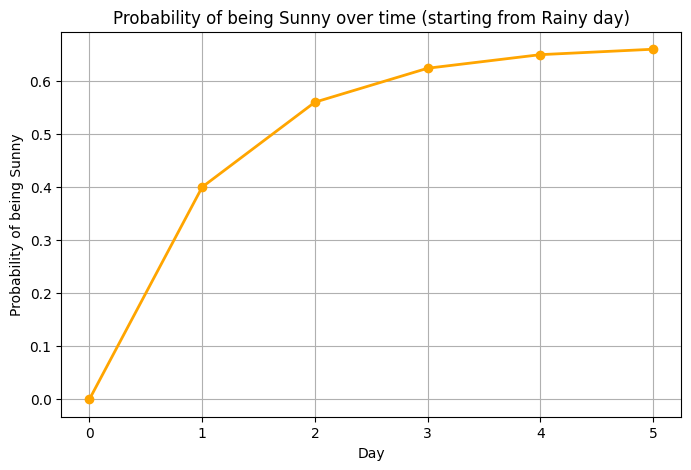

In [26]:
import numpy as np
import matplotlib.pyplot as plt

p = np.array([[0.8, 0.2],
              [0.4, 0.6]])

# Initial state: Rainy (0% Sunny, 100% Rainy)
X = np.array([0.0, 1.0])

days = list(range(6))
sunny_probabilities = [X[0]] # Initialize as a list containing the initial probability of being sunny

for day in range(1, 6):
  X = np.dot(X, p) # Use 'p' (NumPy array) instead of 'P' (dictionary)
  sunny_probabilities.append(X[0])

plt.figure(figsize=(8, 5))
plt.plot(days, sunny_probabilities, marker='o', linestyle='-', color='orange', linewidth=2)
plt.title("Probability of being Sunny over time (starting from Rainy day)")
plt.xlabel("Day")
plt.ylabel("Probability of being Sunny")
plt.grid(True)
plt.show()